# Imported
for better visualization for bar chart

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

def matplotlib_setup(fontsize=45):
    font = {'size'   : fontsize}
    plt.rc('font', **font)
    plt.rcParams["axes.linewidth"]  = 2.5
    plt.grid(linewidth=3,axis='y', color='grey')

    CB91_Blue = '#2CBDFE'
    CB91_Green = '#47DBCD'
    CB91_Pink = '#F3A0F2'
    CB91_Purple = '#9D2EC5'
    CB91_Violet = '#661D98'
    CB91_Amber = '#F5B14C'
    color_list = [CB91_Blue, CB91_Pink, CB91_Green, CB91_Amber,
              CB91_Purple, CB91_Violet]
    
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list)    
    return plt


def extract_sampler_names(dir_names):
    sampler_names = []
    for dir_name in dir_names:
        if 'SFS' in dir_name:
            label = 'SketchFlow Sampling'
        elif 'SGS' in dir_name:
            label = 'Sketch Guided Sampling'
        elif 'SRS' in dir_name:
            label = 'Simple Random Sampling'
        elif 'FFS' in dir_name:
            label = 'Fast Filtered Sampling'
        elif 'WS' in dir_name:
            label = 'Without Sampling'
        else:
            print('Investigate plot_comparison',dir_name)
            
        sampler_names.append(label)
    return sampler_names

: 

# HOTA, LocA, DetA
Performance of YOLOv8 models (n, s, m, l, x) on MOT17 and MOT20 datasets across HOTA, LocA, DetA, and predicted detections (in thousands) at varying confidence thresholds.



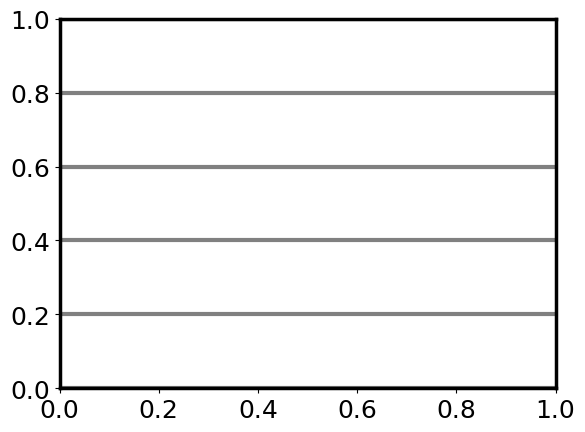

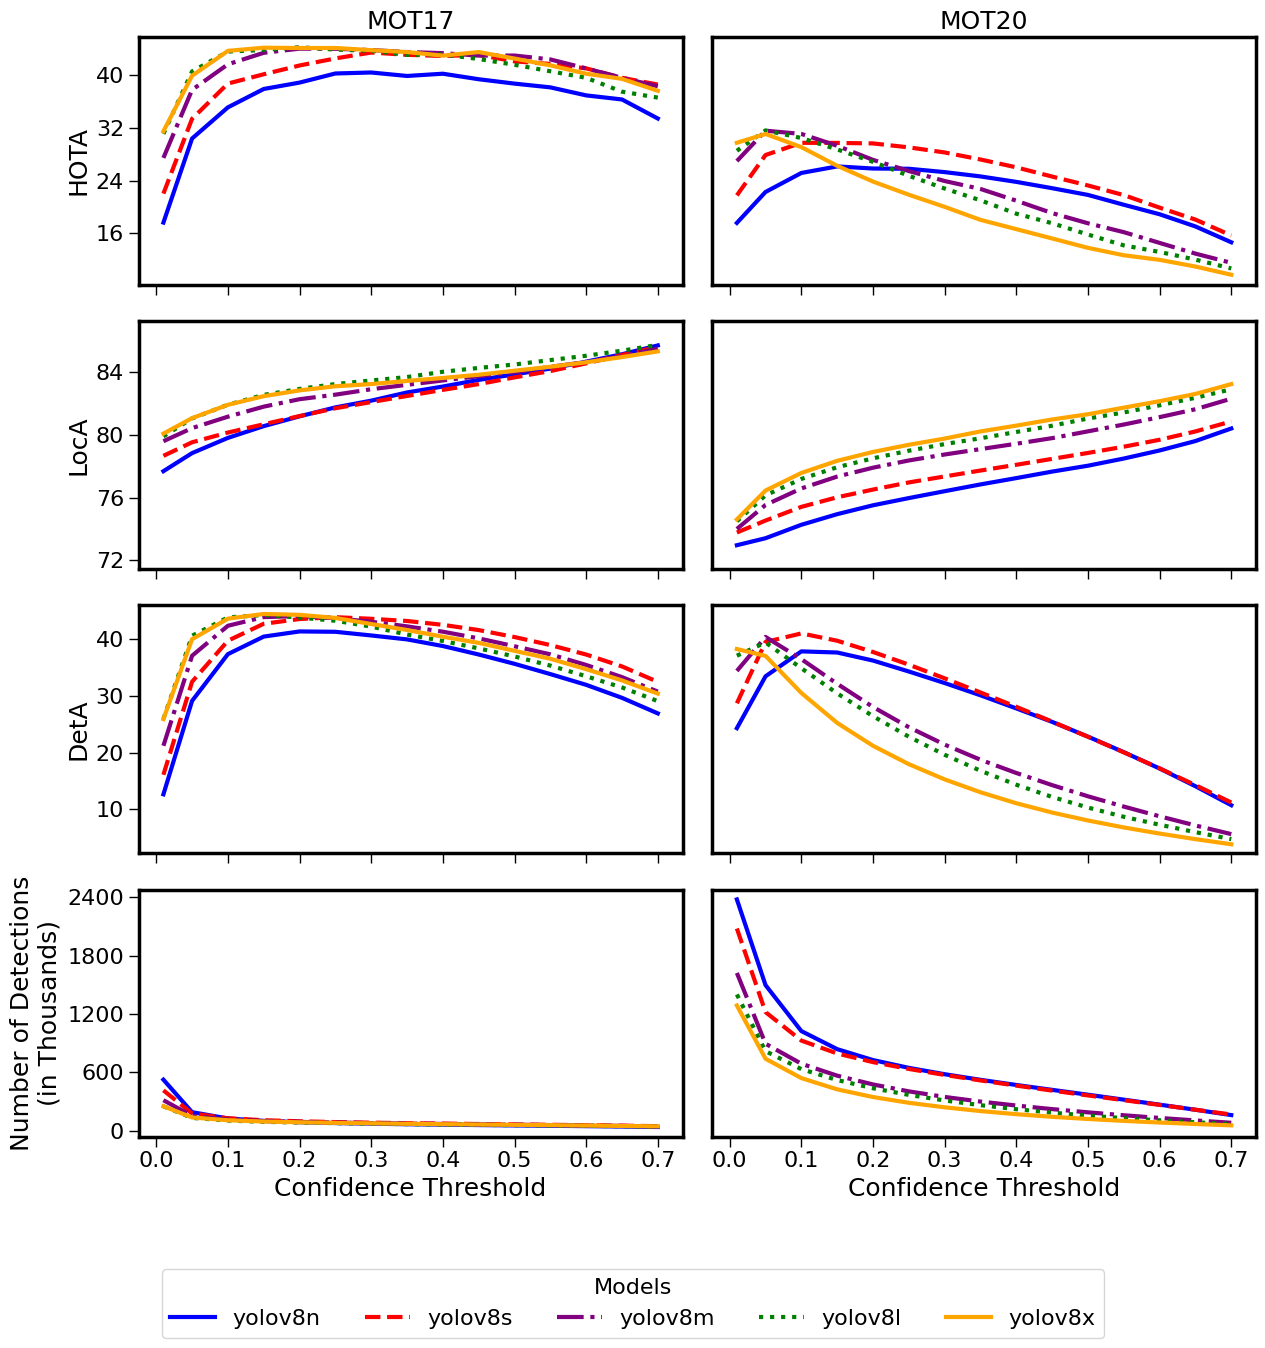

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator

# Setup functions
def matplotlib_setup(fontsize=20):
    font = {'size': fontsize}
    plt.rc('font', **font)
    plt.rcParams["axes.linewidth"] = 2.5
    plt.grid(linewidth=3, axis='y', color='grey')

    CB91_Blue = '#2CBDFE'
    CB91_Green = '#47DBCD'
    CB91_Pink = '#F3A0F2'
    CB91_Purple = '#9D2EC5'
    CB91_Violet = '#661D98'
    CB91_Amber = '#F5B14C'
    color_list = ['blue', 'red', 'purple', 'green', 'orange']

    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list)
    return plt


# Read dataset
data = pd.read_csv('/home/oybek/Desktop/LITE/extracted-datas-for-plot/HOTA.csv')
df = pd.DataFrame(data)

# Plot configuration
metrics = ['HOTA', 'LocA', 'DetA', 'Dets']
datasets = ['MOT17', 'MOT20']
line_styles = ['-', '--', '-.', ':']
sns.set_palette("tab10")

# Normalize 'Dets' for better scaling
df['Dets'] /= 1000

# Plot setup
plt = matplotlib_setup(fontsize=18)
fig, axes = plt.subplots(4, 2, figsize=(13, 15), sharex=True)
plt.subplots_adjust(hspace=0.15, wspace=0.15)
model_order = ['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x']

for i, metric in enumerate(metrics):
    for j, dataset_name in enumerate(datasets):
        ax = axes[i, j]

        # Filter by dataset and sort by 'conf'
        subset = df[df['dataset'] == dataset_name].sort_values(by='conf')

        # Plot each line graph for different models in the specified order
        handles = []
        for model_name in model_order:
            model_data = subset[subset['model'] == model_name]
            if not model_data.empty:
                line, = ax.plot(
                    model_data['conf'], 
                    model_data[metric], 
                    linewidth=3,
                    label=f'{model_name}', 
                    linestyle=line_styles[model_order.index(model_name) % len(line_styles)],
                )
                handles.append(line)

        # Configure axis labels and titles based on position
        ax.tick_params(axis='both', which='major', labelsize=18, length=7, width=1)
        ax.tick_params(axis='both', which='minor', labelsize=18, length=4, width=1)
        if j == 0:
            ax.set_ylabel(metric, fontsize=18)
        if i == 0:
            ax.set_title(f"{dataset_name}", fontsize=18)
        if i == len(metrics) - 1:
            ax.set_xlabel('Confidence Threshold', fontsize=18)
        if (i == len(metrics) - 1) and (j == 0):
            ax.set_ylabel('Number of Detections\n(in Thousands)', fontsize=18)
        # Set tick parameters and limits
        ax.tick_params(axis='x', labelsize=16)
        ax.tick_params(axis='y', labelsize=16)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        if dataset_name == 'MOT20':
            ax.set_yticks([])
   
    
    min_val = df[metric].min() - 1.5
    max_val = df[metric].max() + 1.5

    if metric == 'Dets':
        min_val -= 100
        max_val += 100
    
        
    # Apply the same y-limits to all subplots in the same row
    for j in range(len(datasets)):
        axes[i, j].set_ylim(min_val, max_val)

# Ensure the y-axis range is the same for each row (each metric)

# Manually specify the legend order
fig.legend(handles, model_order, loc='upper center', bbox_to_anchor=(0.5, 0.1), ncol=5, fontsize=16, title='Models', title_fontsize=16, handlelength=2)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])

# Save and display plot
plt.savefig("/home/oybek/Desktop/LITE/plots/HOTA.csv", format="pdf", bbox_inches="tight")
plt.show()


# AssA, AssRe and AssPr 
Performance of YOLOv8 models (n, s, m, l, x) on MOT17 and MOT20 datasets across HOTA, LocA, DetA, and predicted detections (in thousands) at varying confidence thresholds.


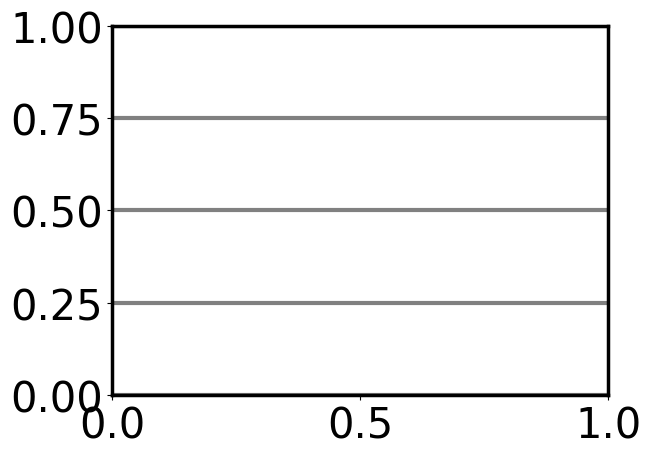

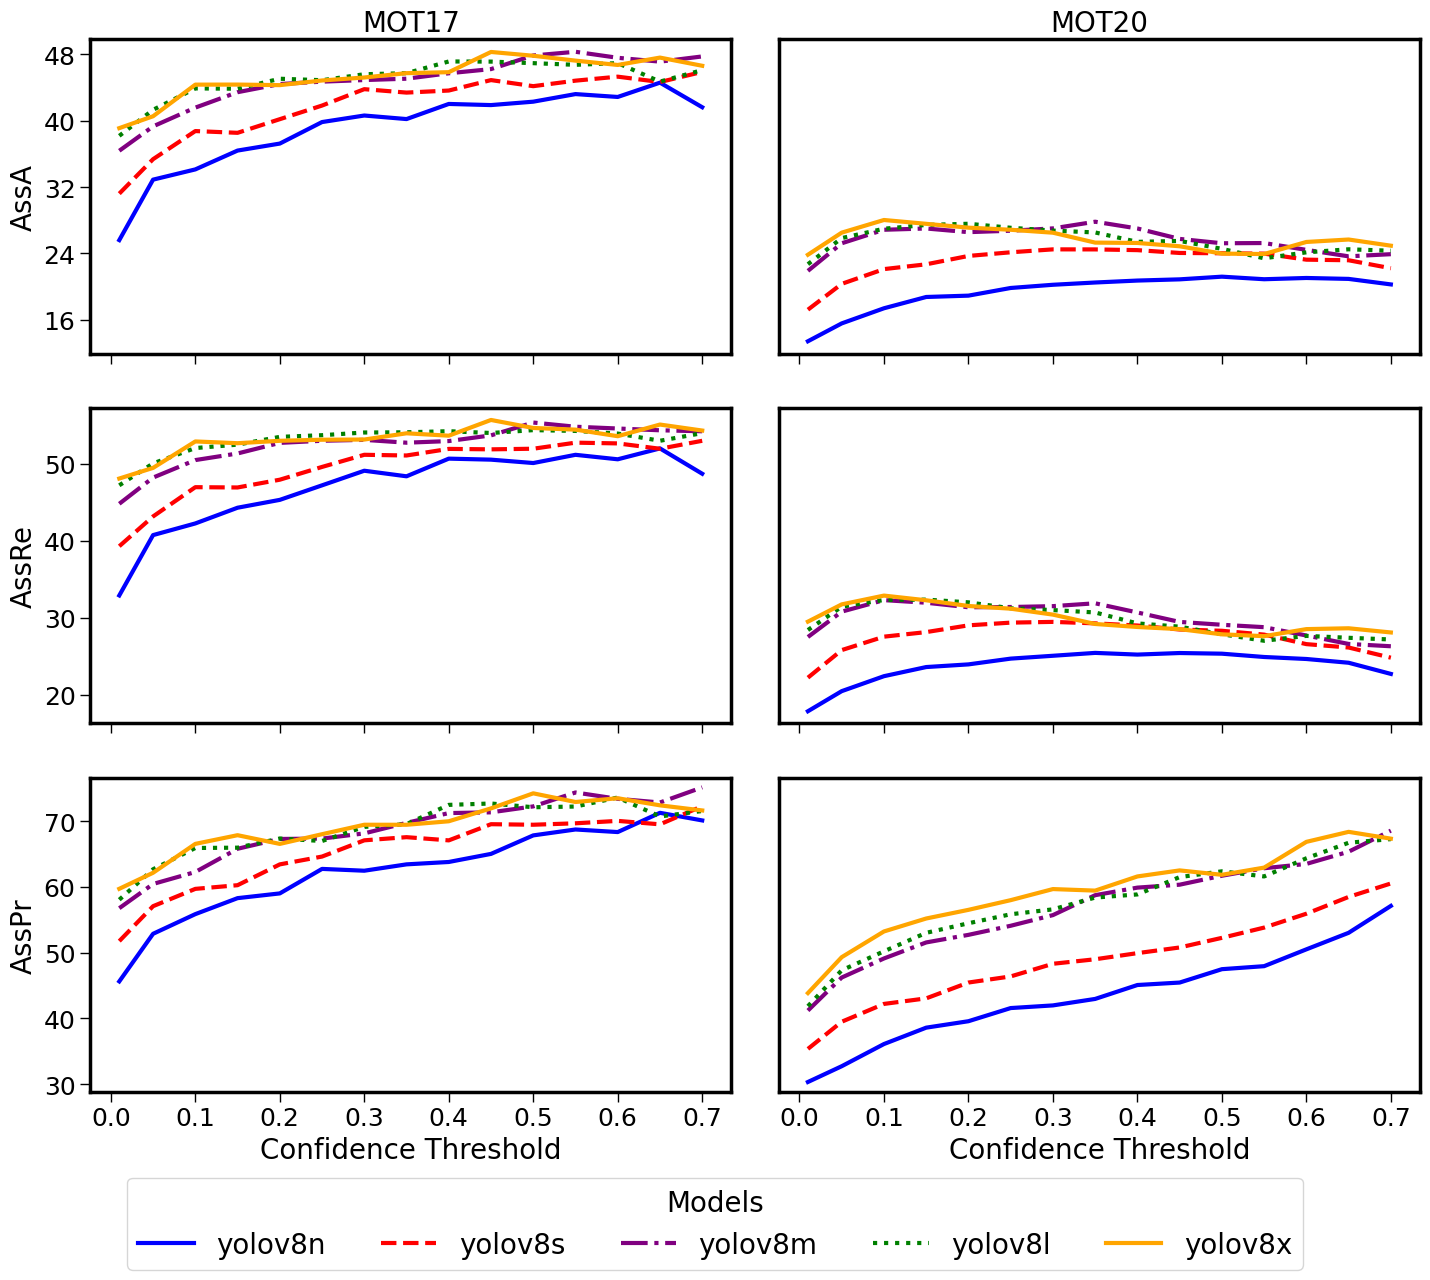

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator

def matplotlib_setup(fontsize=45):
    font = {'size': fontsize}
    plt.rc('font', **font)
    plt.rcParams["axes.linewidth"] = 2.5
    plt.grid(linewidth=3, axis='y', color='grey')

    CB91_Blue = '#2CBDFE'
    CB91_Green = '#47DBCD'
    CB91_Pink = '#F3A0F2'
    CB91_Purple = '#9D2EC5'
    CB91_Violet = '#661D98'
    CB91_Amber = '#F5B14C'
    color_list = [CB91_Blue, CB91_Pink, CB91_Green, CB91_Amber, CB91_Purple, CB91_Violet]

    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list)
    return plt

def plot_metrics(data_path, save_path):
    # Read and prepare data
    data = pd.read_csv(data_path)
    df = pd.DataFrame(data)

    # Configure plot setup
    matplotlib_setup(fontsize=30)

    metrics = ['AssA', 'AssRe', 'AssPr']
    datasets = ['MOT17', 'MOT20']

    fig, axes = plt.subplots(3, 2, figsize=(15, 15), sharex=True)
    plt.subplots_adjust(hspace=0.15, wspace=0.15)
    model_order = ['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x']
    line_styles = ['-', '--', '-.', ':']
    color_list = ['blue', 'red', 'purple', 'green', 'orange']  # Custom colors

    for i, metric in enumerate(metrics):
        for j, dataset_name in enumerate(datasets):
            ax = axes[i, j]

            # Filter by dataset and sort by 'conf'
            subset = df[df['dataset'] == dataset_name].sort_values(by='conf')

            # Plot each line graph for different models in the specified order
            handles = []
            for idx, model_name in enumerate(model_order):
                model_data = subset[subset['model'] == model_name]
                if not model_data.empty:
                    line, = ax.plot(
                        model_data['conf'], 
                        model_data[metric], 
                        linewidth=3,
                        label=f'{model_name}', 
                        linestyle=line_styles[idx % len(line_styles)],
                        color=color_list[idx % len(color_list)]  # Use custom color
                    )
                    handles.append(line)

            # Configure axis labels and titles based on position
            ax.tick_params(axis='both', which='major', labelsize=20, length=7, width=1)
            ax.tick_params(axis='both', which='minor', labelsize=20, length=4, width=1)
            if j == 0:
                ax.set_ylabel(metric, fontsize=20)
            if i == 0:
                ax.set_title(f"{dataset_name}", fontsize=20)
            if i == len(metrics) - 1:
                ax.set_xlabel('Confidence Threshold', fontsize=20)

            ax.tick_params(axis='x', labelsize=18)
            ax.tick_params(axis='y', labelsize=18)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            if dataset_name == 'MOT20':
                ax.set_yticks([])
            
        min_val = df[metric].min() - 1.5
        max_val = df[metric].max() + 1.5
        
        # Apply the same y-limits to all subplots in the same row
        for j in range(len(datasets)):
            axes[i, j].set_ylim(min_val, max_val)
    
    # Display legend only if handles are present
    if handles:
        fig.legend(handles, model_order, loc='upper center', bbox_to_anchor=(0.5, 0.15), ncol=5, fontsize=20, title='Models', title_fontsize=20, handlelength=2)

    plt.tight_layout(rect=[0, 0.12, 1, 0.95])
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    plt.show()

# Usage
plot_metrics('/home/oybek/Desktop/LITE/extracted-datas-for-plot/HOTA.csv', '/home/oybek/Desktop/LITE/plots/AssA.pdf')


# Ablation Studies


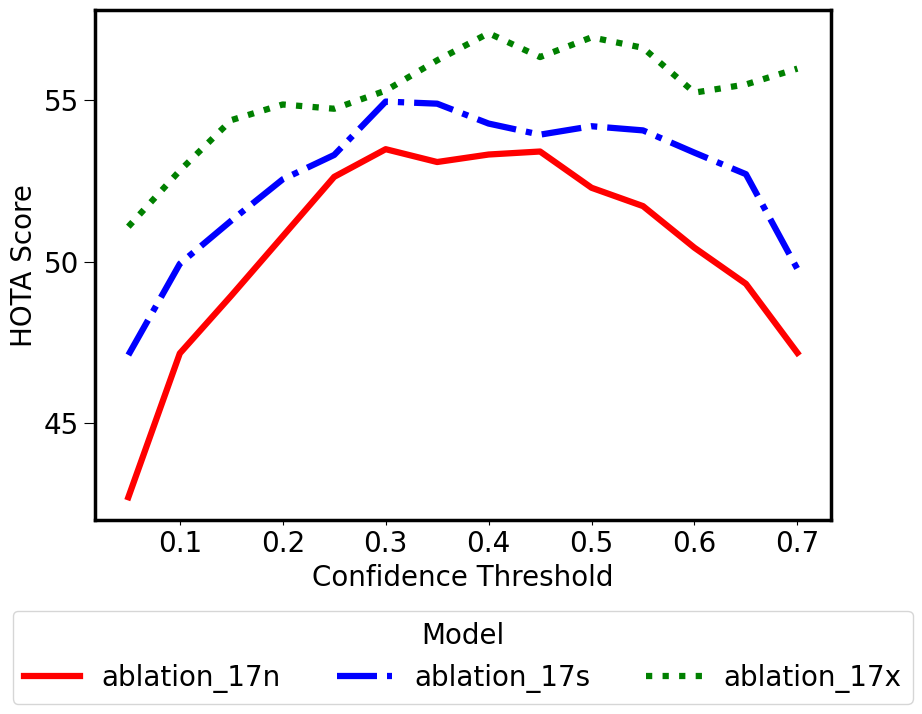

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data from the CSV
data = pd.read_csv('/home/oybek/Desktop/LITE/extracted-datas-for-plot/ablation.csv')

# Sort the data by 'conf'
data_sorted = data.sort_values(by='conf')

# Define the model order explicitly
model_order = ['ablation_17n', 'ablation_17s', 'ablation_17x']

# Set up the plot
plt.figure(figsize=(10, 8))

# Define colors and linestyles
colors = ['red', 'blue', 'green']
line_styles = ['-', '-.', ':']

# Plot each model in the specified order
for idx, model in enumerate(model_order):
    model_data = data_sorted[data_sorted['model'] == model]
    plt.plot(
        model_data['conf'],
        model_data['HOTA'],
        label=model,
        color=colors[idx % len(colors)],
        linestyle=line_styles[idx % len(line_styles)],
        linewidth=4.5
    )

# Customize the plot
plt.xlabel('Confidence Threshold', fontsize=20)
plt.ylabel('HOTA Score', fontsize=20)
plt.xticks(np.arange(0.1, 0.8, 0.1), fontsize=20)  # Set x-axis ticks from 0.1 to 0.7 with 0.1 interval
plt.yticks(fontsize=20)
plt.tick_params(axis='y', which='major', length=8)

# Add legend below the plot and centered with a larger title size
plt.legend(
    title='Model', title_fontsize=20, fontsize=20, 
    loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3
)

# Show the plot
plt.tight_layout()
plt.savefig("/home/oybek/Desktop/LITE/plots/ablation_graph.pdf", format="pdf", bbox_inches="tight")
plt.show()


# Bar chart

Comparison of YOLOv8 Models (n, s, m, l, x) on the MOT20 dataset, illustrating variations in HOTA across different model sizes, confidence levels, and tracking algorithms. Bar charts for each tracker are included to provide a clearer visualization of performance changes at varying confidence threshold.


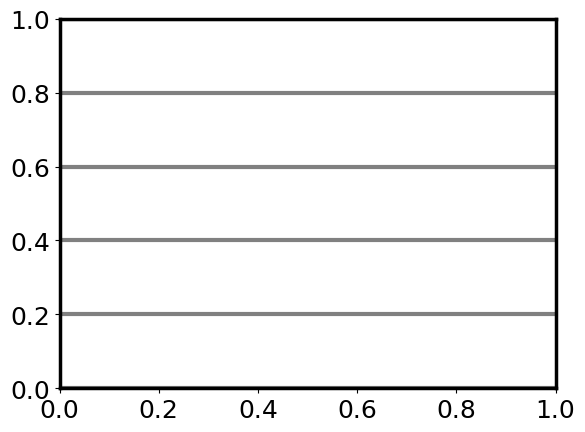

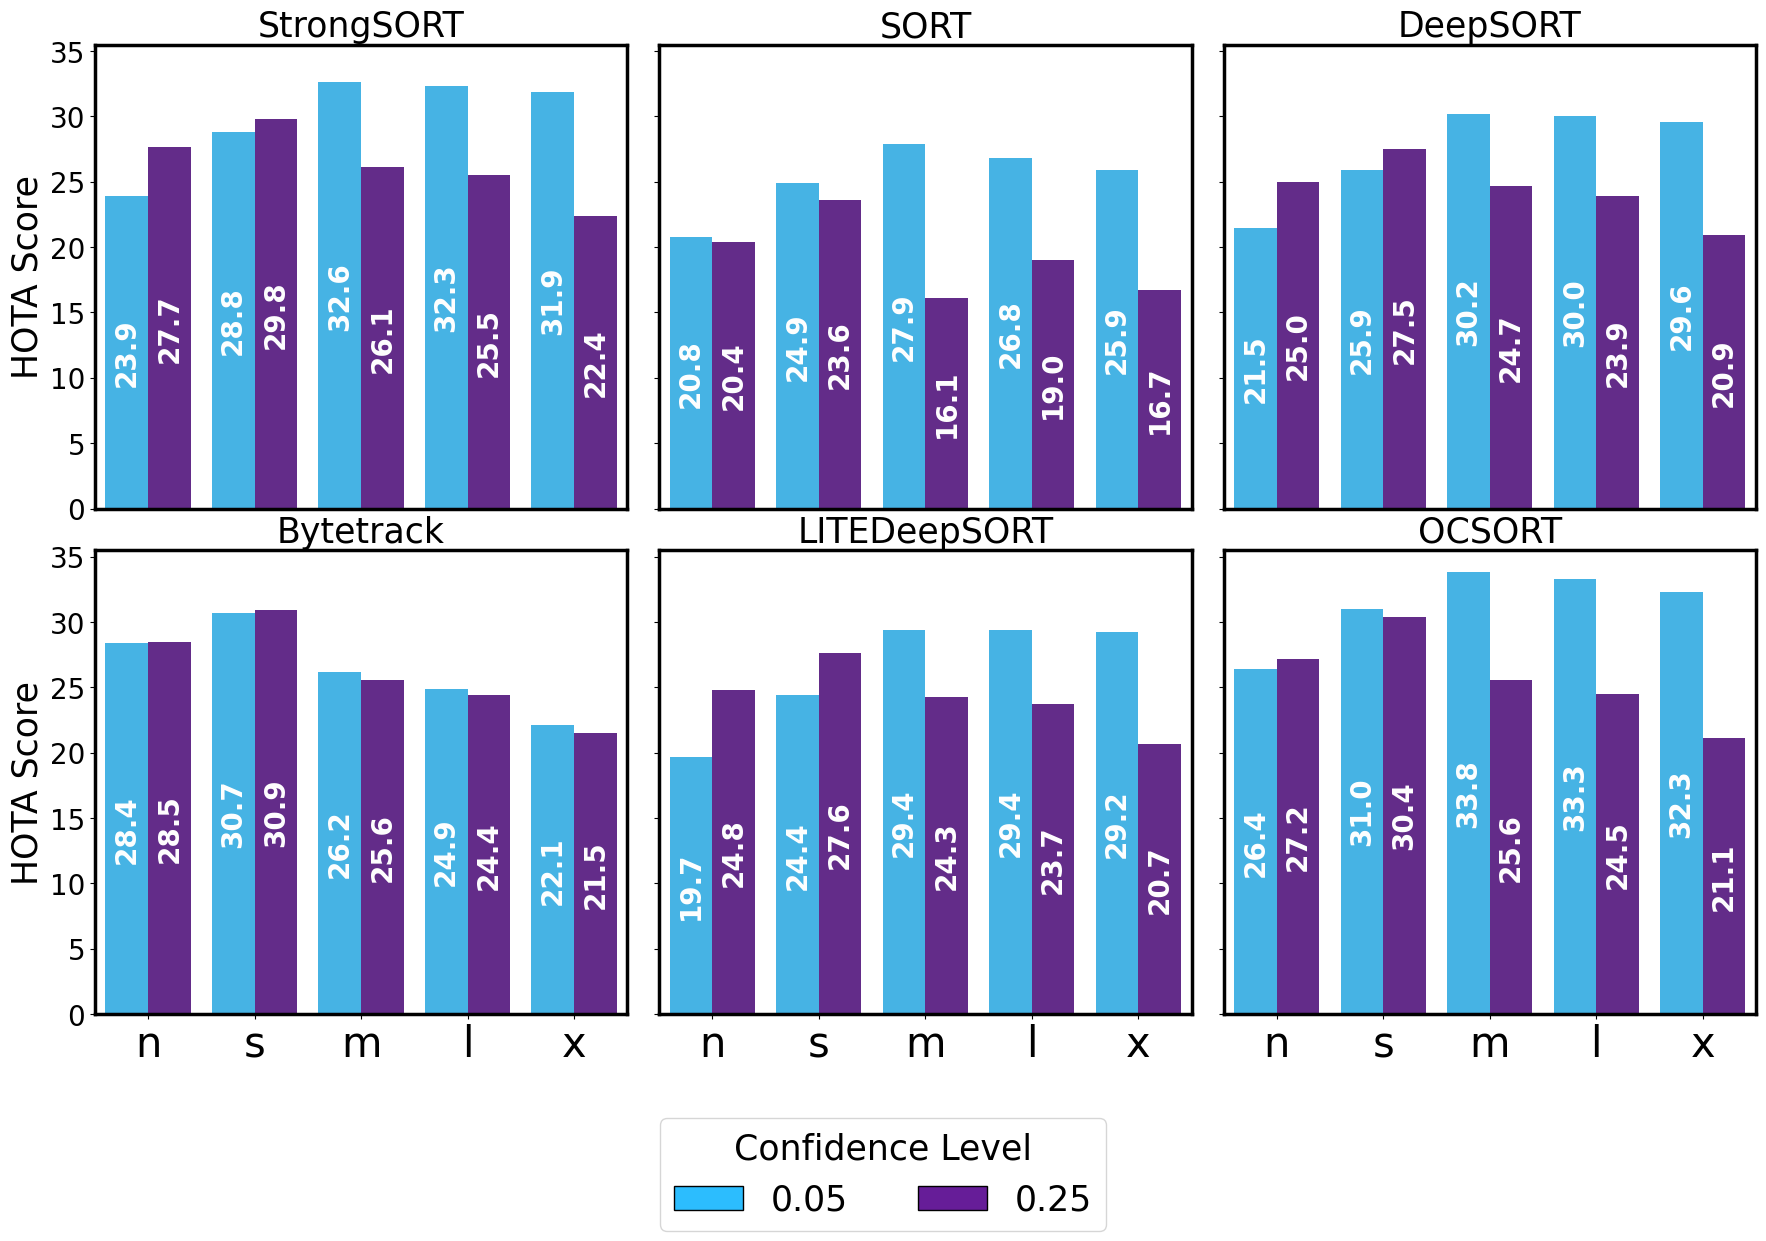

In [9]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch  # For custom legend

def matplotlib_setup(fontsize=45):
    font = {'size': fontsize}
    plt.rc('font', **font)
    plt.rcParams["axes.linewidth"] = 2.5
    plt.grid(linewidth=3, axis='y', color='grey')

    CB91_Blue = '#2CBDFE'
    CB91_Green = '#47DBCD'
    CB91_Pink = '#F3A0F2'
    CB91_Purple = '#9D2EC5'
    CB91_Violet = '#661D98'
    CB91_Amber = '#F5B14C'
    color_list = [CB91_Blue, CB91_Pink, CB91_Green, CB91_Amber, CB91_Purple, CB91_Violet]

    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list)
    return plt, CB91_Blue, CB91_Violet

# Load data
df = pd.read_csv("/home/oybek/Desktop/LITE/extracted-datas-for-plot/your_file.csv", dtype=str)

# Convert necessary columns back to numeric
numeric_columns = ["HOTA", "AssA", "AssRe", "AssPr", "LocA", "DetA", "Dets", "GT_IDs", "IDs", "resolution"]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric)

# Round HOTA score to 1 decimal place
df["HOTA"] = df["HOTA"].round(1)

# Ensure categorical columns remain strings
df["tracker"] = df["tracker"].astype(str)
df["model"] = df["model"].astype(str)
df["dataset"] = df["dataset"].astype(str)
df["conf"] = df["conf"].astype(str)

# Extract the last character of model names for labeling
df["model_label"] = df["model"].apply(lambda x: x[-1])

# Define model order
model_order = ["n", "s", "m", "l", "x"]

# Filter only required confidence levels
df_filtered = df[df["conf"].isin(["0.05", "0.25"])]

# Define tracker groups
trackers_row1 = ["StrongSORT", "SORT", "DeepSORT"]
trackers_row2 = [t for t in df_filtered["tracker"].unique() if t not in trackers_row1]

# Setup plot with custom configurations
plt, blue_color, violet_color = matplotlib_setup(fontsize=18)

# Define custom palette
palette = {"0.05": blue_color, "0.25": violet_color}
text_size = 25

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=max(len(trackers_row1), len(trackers_row2)), figsize=(18, 12), sharey=True)

# Plot first row
for i, tracker in enumerate(trackers_row1):
    ax = axes[0, i]
    df_tracker = df_filtered[df_filtered["tracker"] == tracker]

    bars = sns.barplot(
    data=df_tracker,
    x="model_label",
    y="HOTA",
    hue="conf",
    order=model_order,
    hue_order=["0.05", "0.25"],  # Explicitly define hue order
    ax=ax,
    palette=palette,
    dodge=True
)
    ax.tick_params(axis='x', labelsize=30)
    ax.tick_params(axis='y', labelsize=20)

    ax.set_xticks([])


    # Add values inside bars vertically centered
    for bar_container in bars.containers:
        for bar in bar_container:
            height = bar.get_height()
            bars.text(
                bar.get_x() + bar.get_width() / 2,
                height / 2,
                f"{height:.1f}",
                ha='center', va='center',
                rotation='vertical',
                color='white', fontsize=20, fontweight='bold'
            )

    ax.set_title(tracker, fontsize=text_size)
    ax.set_xlabel(" ")
    ax.set_ylabel("HOTA Score", fontsize=text_size)
    ax.get_legend().remove()

# Plot second row
for i, tracker in enumerate(trackers_row2):
    ax = axes[1, i]
    df_tracker = df_filtered[df_filtered["tracker"] == tracker]

    bars = sns.barplot(
    data=df_tracker,
    x="model_label",
    y="HOTA",
    hue="conf",
    order=model_order,
    hue_order=["0.05", "0.25"],  # Explicitly define hue order
    ax=ax,
    palette=palette,
    dodge=True
)
    ax.tick_params(axis='x', labelsize=30)
    ax.tick_params(axis='y', labelsize=20)

    # Add values inside bars vertically centered
    for bar_container in bars.containers:
        for bar in bar_container:
            height = bar.get_height()
            bars.text(
                bar.get_x() + bar.get_width() / 2,
                height / 2,
                f"{height:.1f}",
                ha='center', va='center',
                rotation='vertical',
                color='white', fontsize=20, fontweight='bold'
            )

    ax.set_title(tracker, fontsize=text_size)
    ax.set_xlabel(" ")
    ax.set_ylabel("HOTA Score", fontsize=text_size)
    ax.get_legend().remove()

# Create and add custom legend
legend_handles = [Patch(facecolor=color, edgecolor='black', label=f"{conf}") for conf, color in palette.items()]
fig.legend(
    handles=legend_handles, 
    title="Confidence Level", 
    loc="lower center", 
    ncol=2, 
    frameon=True,
    fontsize=text_size,  
    title_fontsize=text_size,  
    bbox_to_anchor=(0.5, -0.055)
)

# Adjust layout
plt.tight_layout(rect=[0, 0.05, 1, 1])
# Save the plot
plt.subplots_adjust(hspace=0.09)  # Further reduce vertical space
plt.savefig('hota_scores_accros_trackers.pdf', bbox_inches='tight')

# Show the plot
plt.show()

# HOTA SCORE with diffirent conf lvl across 11 Tracker
Average HOTA scores of trackers deploying YOLOv8m and YOLO11m models across different confidence thresholds, illustrating YOLO11m’s strength at lower thresholds and YOLOv8m’s superior performance at higher thresholds.

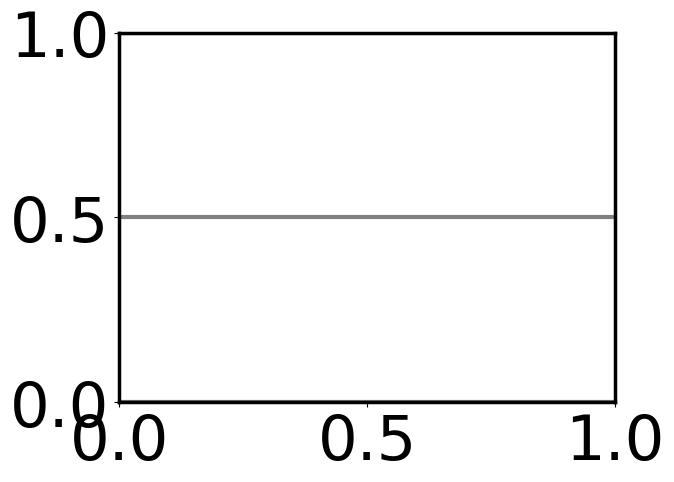

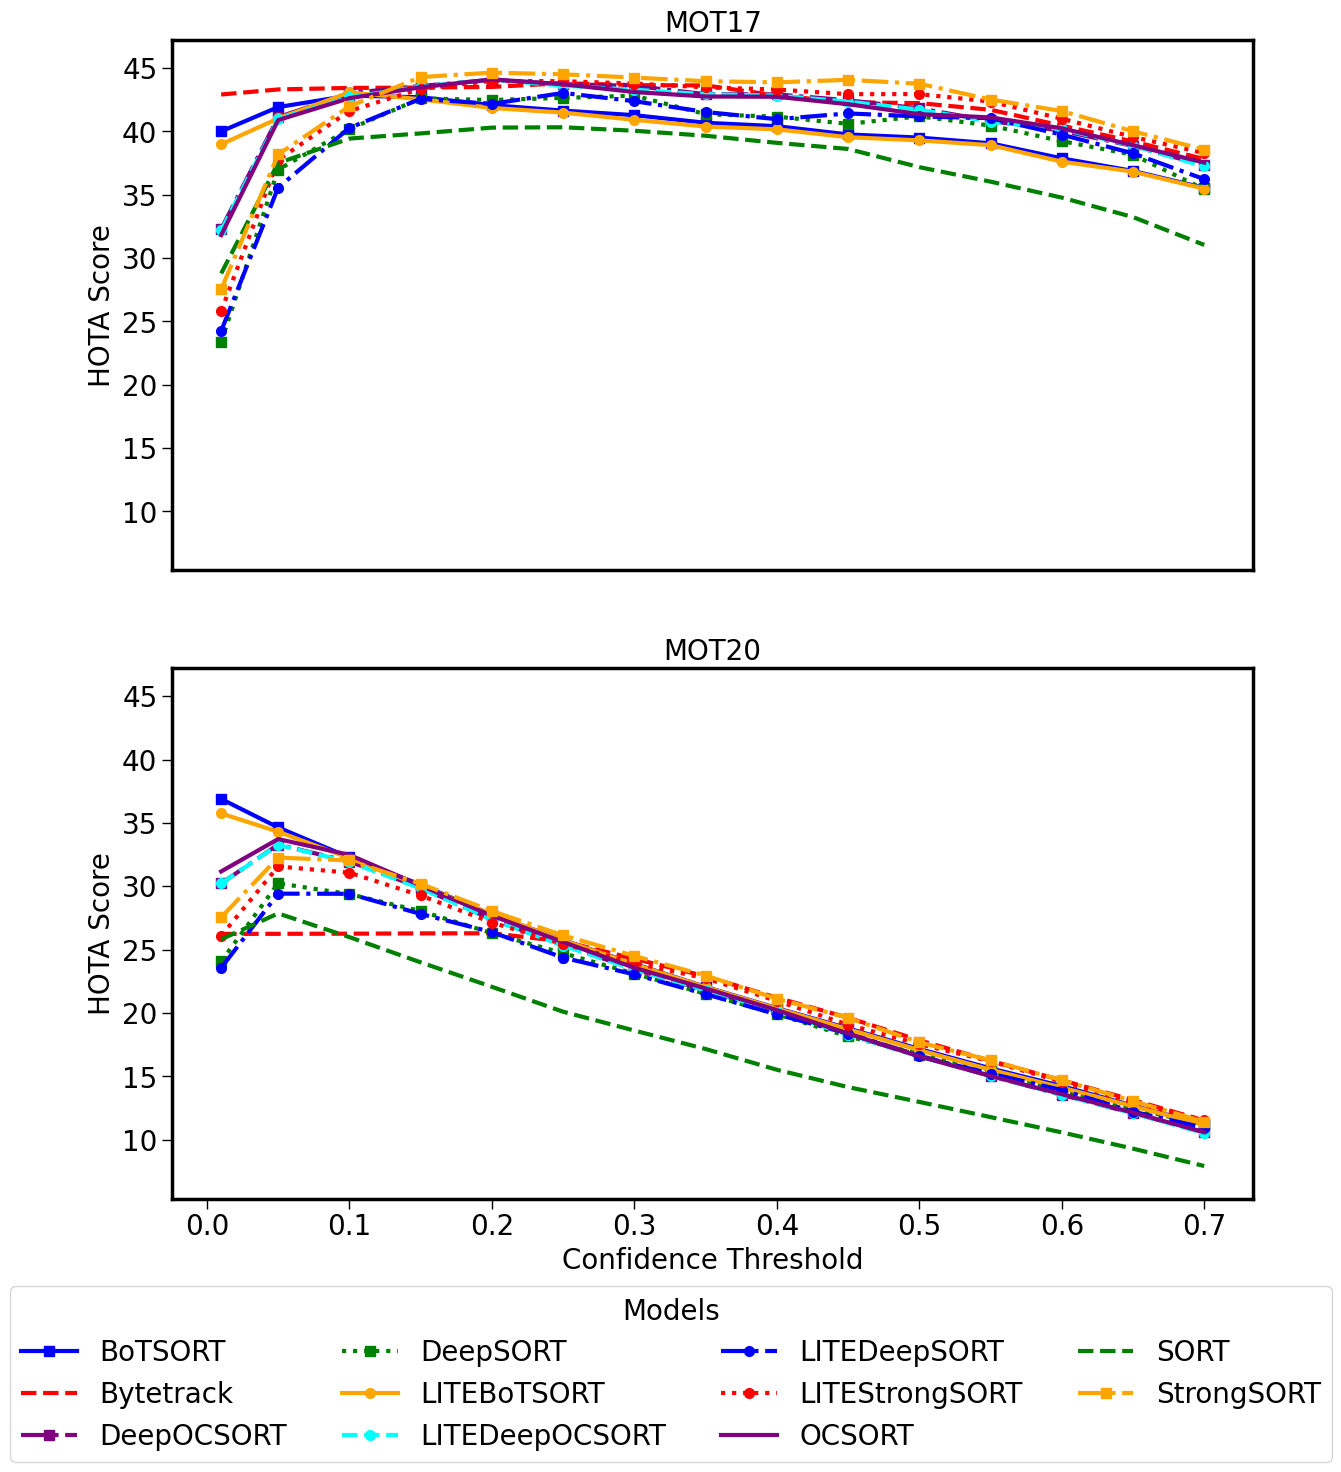

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.pyplot import figure

def matplotlib_setup(fontsize=45):
    # Define custom colors
    color_list = ['blue', 'red', 'purple', 'green', 'orange', 'cyan', 'magenta', 'yellow', 'black', 'brown', 'pink']
    
    # Apply Seaborn color palette
    sns.set_palette(color_list)
    
    # Apply font size and other matplotlib settings
    font = {'size': fontsize}
    plt.rc('font', **font)
    plt.rcParams["axes.linewidth"] = 2.5
    plt.grid(linewidth=3, axis='y', color='grey')
    
    # Set the color cycle for matplotlib
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list)    
    return plt
def create_tracking_plots(data_path, fontsize=45):
    # Apply custom matplotlib settings
    matplotlib_setup(fontsize)

    # Read CSV file
    df = pd.read_csv(data_path)

    # Create figure with two subplots arranged in 2 rows
    fig, axs = plt.subplots(2, 1, figsize=(13, 14), sharex=True)

    # Define line styles
    line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
    
    # Define custom colors
    color_list = ['blue', 'red', 'purple', 'green', 'orange', 'cyan']

    # Compute global min and max HOTA scores across both datasets
    global_min_hota = df['HOTA'].min()
    global_max_hota = df['HOTA'].max()
    padding = (global_max_hota - global_min_hota) * 0.07  # 7% padding

    # Adjusted limits for uniform y-axis range
    y_min = global_min_hota - padding
    y_max = global_max_hota + padding

    # Plot for MOT17 and MOT20
    all_handles = []  # Collect handles for combined legend
    all_labels = []

    for ax, dataset_name in zip(axs, ['MOT17', 'MOT20']):
        dataset_data = df[df['dataset'] == dataset_name]
        if dataset_data.empty:
            print(f"No data for {dataset_name}. Skipping plot.")
            continue

        trackers = sorted(dataset_data['tracker'].unique())  # Ensure ordered legend
        for idx, tracker in enumerate(trackers):
            tracker_data = dataset_data[dataset_data['tracker'] == tracker].sort_values('conf')

            if tracker.startswith('LITE'):
                marker = 'o' 
            elif tracker in ['DeepSORT', 'BoTSORT', 'StrongSORT', 'DeepOCSORT']:
                marker = 's'
            else: 
                marker = None

            line = ax.plot(tracker_data['conf'], tracker_data['HOTA'],
                             label=tracker,
                             linestyle=line_styles[idx % len(line_styles)],
                             linewidth=3,
                             marker=marker,
                             markersize=7 if marker else 0,
                             color=color_list[idx % len(color_list)])  # Explicit color setting
                             
            if tracker not in all_labels:
                all_labels.append(tracker)
                all_handles.append(line[0])

        # Set the same y-axis range for both subplots
        ax.set_ylim(y_min, y_max)

        ax.set_title(f'{dataset_name}', fontsize=20)
        if dataset_name != 'MOT17':
            ax.set_xlabel('Confidence Threshold', fontsize=20)
        ax.set_ylabel('HOTA Score', fontsize=20)
        if dataset_name == 'MOT17':
          ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Fully removes x-ticks


        # Increase tick sizes
        ax.tick_params(axis='both', which='major', labelsize=20, length=7, width=1)
        ax.tick_params(axis='both', which='minor', labelsize=20, length=4, width=1)

        ax.grid(False)  # Remove grid

    # Create a single combined legend below the subplots
    fig.legend(all_handles, all_labels, loc='upper center',
               bbox_to_anchor=(0.5, 0.05), ncol=4, fontsize=20,
               title='Models', title_fontsize=20)

    plt.subplots_adjust(hspace=0.3)
    plt.tight_layout()
    plt.savefig("/home/oybek/Desktop/LITE/plots/Final_1280.pdf", format="pdf", bbox_inches="tight")
    plt.show()

# Example usage
create_tracking_plots('/home/oybek/Desktop/LITE/extracted-datas-for-plot/Final_1280.csv')
